Name: Boga Petruska and Bence Szabo\
Class: ECBS5171 - Data Analysis 3\
Assignment: Assignment 2 - Fast Growth Prediction\
Date: Feb 15, 2026

Data Engineering Notebook

In [28]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.nonparametric.smoothers_lowess import lowess

import warnings
warnings.filterwarnings('ignore')

In [29]:
csv_path = "../data/clean/cs_bisnode_panel.csv"
data = pd.read_csv(csv_path)

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 287829 entries, 0 to 287828
Data columns (total 48 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   comp_id               287829 non-null  float64
 1   begin                 287829 non-null  object 
 2   end                   287829 non-null  object 
 3   COGS                  18257 non-null   float64
 4   amort                 279789 non-null  float64
 5   curr_assets           287698 non-null  float64
 6   curr_liab             287698 non-null  float64
 7   extra_exp             269300 non-null  float64
 8   extra_inc             269300 non-null  float64
 9   extra_profit_loss     270626 non-null  float64
 10  finished_prod         17485 non-null   float64
 11  fixed_assets          287698 non-null  float64
 12  inc_bef_tax           280392 non-null  float64
 13  intang_assets         287689 non-null  float64
 14  inventories           287698 non-null  float64
 15  

In [30]:
# Check missing values across all columns
na_summary = (
    data.isnull()
    .sum()
    .to_frame("missing_count")
    .assign(
        total=len(data),
        pct_missing=lambda df: (df["missing_count"] / df["total"] * 100).round(1)
    )
    .sort_values("pct_missing", ascending=False)
)

# Show columns with >50% missing
na_summary.query("pct_missing > 50")

,missing_count,total,pct_missing
D,287829,287829,100.0
finished_prod,270344,287829,93.9
wages,269846,287829,93.8
COGS,269572,287829,93.7
net_exp_sales,269572,287829,93.7
net_dom_sales,269572,287829,93.7
exit_year,248970,287829,86.5
exit_date,231649,287829,80.5
labor_avg,146532,287829,50.9


In [31]:
# Drop columns with >50% missing as unusable for modeling
drop_cols = na_summary.query("pct_missing > 50").index.tolist()
print(f"Dropping {len(drop_cols)} columns: {drop_cols}")
data = data.drop(columns=drop_cols)

Dropping 9 columns: ['D', 'finished_prod', 'wages', 'COGS', 'net_exp_sales', 'net_dom_sales', 'exit_year', 'exit_date', 'labor_avg']


In [32]:
# Keep 2010–2015 panel per assignment requirements
data = data.query("year >= 2010 & year <= 2015")

## Label Engineering

In [33]:
# Balance the panel — fill all comp_id × year combinations
data = (
    data.set_index(["year", "comp_id"])
    .unstack(fill_value="toReplace")
    .stack()
    .reset_index()
)
data = data.replace("toReplace", np.nan)

In [34]:
print(f"Panel: {data['comp_id'].nunique():,} firms x "
      f"{data['year'].nunique()} years = {len(data):,} rows")

Panel: 39,375 firms x 6 years = 236,250 rows


In [35]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 236250 entries, 0 to 236249
Data columns (total 39 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   year                  236250 non-null  int64  
 1   comp_id               236250 non-null  float64
 2   begin                 167606 non-null  object 
 3   end                   167606 non-null  object 
 4   amort                 163489 non-null  float64
 5   curr_assets           167549 non-null  float64
 6   curr_liab             167549 non-null  float64
 7   extra_exp             163855 non-null  float64
 8   extra_inc             163855 non-null  float64
 9   extra_profit_loss     163851 non-null  float64
 10  fixed_assets          167549 non-null  float64
 11  inc_bef_tax           163864 non-null  float64
 12  intang_assets         167549 non-null  float64
 13  inventories           167549 non-null  float64
 14  liq_assets            167549 non-null  float64
 15  

In [36]:
# fast_growth target variable

# definition: OECD-adapted 2-year CAGR ≥ 20% annualized
# formula: (sales_2014 / sales_2012)^(1/2) - 1 >= 0.20
# ============================================================

# extract sales by year for each firm
sales_2012 = (
    data.query("year == 2012")[["comp_id", "sales"]]
    .rename(columns={"sales": "sales_2012"})
)
sales_2014 = (
    data.query("year == 2014")[["comp_id", "sales"]]
    .rename(columns={"sales": "sales_2014"})
)

# merge both years to create firm-level growth table
growth = sales_2012.merge(sales_2014, on="comp_id", how="left")

print(f"Firms with 2012 sales: {sales_2012['sales_2012'].notna().sum():,}")
print(f"Firms with 2014 sales: {growth['sales_2014'].notna().sum():,}")
print(f"Firms missing 2014 sales (exited or missing): "
      f"{growth['sales_2014'].isna().sum():,}")

Firms with 2012 sales: 27,446
Firms with 2014 sales: 28,050
Firms missing 2014 sales (exited or missing): 11,325


In [38]:
# compute 2-year CAGR
# 0nly meaningful where both years have sales > 0
growth["cagr_2y"] = np.where(
    (growth["sales_2012"] > 0) & (growth["sales_2014"] > 0),
    (growth["sales_2014"] / growth["sales_2012"]) ** (1 / 2) - 1,
    np.nan
)

# threshold of 20% yearly growth
growth["fast_growth"] = np.where(
    growth["cagr_2y"] >= 0.20, 1,
    np.where(growth["cagr_2y"].isna(), np.nan, 0)
)

# summary stats
print(f"\nCAGR distribution (where computable):")
print(growth["cagr_2y"].describe().round(3))
print(f"\nFast-growth label distribution:")
print(growth["fast_growth"].value_counts(dropna=False))
print(f"\nFast-growth rate: "
      f"{growth['fast_growth'].mean():.1%} of firms with valid data")


CAGR distribution (where computable):
count    17927.000
mean         0.404
std          4.081
min         -0.995
25%         -0.103
50%          0.061
75%          0.266
max        369.725
Name: cagr_2y, dtype: float64

Fast-growth label distribution:
fast_growth
NaN    21448
0.0    12438
1.0     5489
Name: count, dtype: int64

Fast-growth rate: 30.6% of firms with valid data


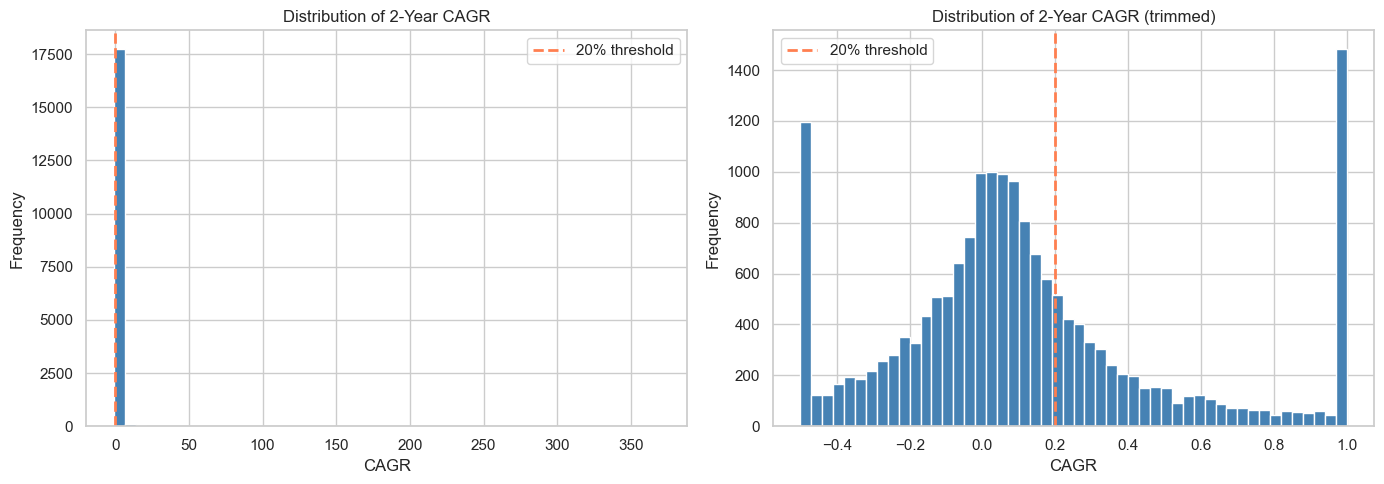

In [39]:
# distribution of growth rates - to support the 20% threshold choice
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Full distribution
axes[0].hist(growth["cagr_2y"].dropna(), bins=50, color="steelblue", edgecolor="white")
axes[0].axvline(x=0.20, color="coral", linestyle="--", linewidth=2, label="20% threshold")
axes[0].set_title("Distribution of 2-Year CAGR")
axes[0].set_xlabel("CAGR")
axes[0].set_ylabel("Frequency")
axes[0].legend()

# Zoomed to -50% to +100%
cagr_trimmed = growth["cagr_2y"].dropna().clip(-0.5, 1.0)
axes[1].hist(cagr_trimmed, bins=50, color="steelblue", edgecolor="white")
axes[1].axvline(x=0.20, color="coral", linestyle="--", linewidth=2, label="20% threshold")
axes[1].set_title("Distribution of 2-Year CAGR (trimmed)")
axes[1].set_xlabel("CAGR")
axes[1].set_ylabel("Frequency")
axes[1].legend()

plt.tight_layout()
plt.savefig("../outputs/cagr_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# quick sanity check: what does the rate look like within the ch17 sales range?
preview = growth.merge(
    data.query("year == 2012")[["comp_id", "sales"]], on="comp_id"
)
preview["sales_mil"] = preview["sales"] / 1e6
filtered = preview.query("sales_mil >= 0.001 & sales_mil <= 10")

print(f"After sales filter: {filtered['fast_growth'].mean():.1%} "
      f"fast-growth ({int(filtered['fast_growth'].sum()):,} of "
      f"{filtered['fast_growth'].notna().sum():,} firms)")

After sales filter: 29.7% fast-growth (5,120 of 17,255 firms)


In [12]:
# merge label back to the main panel for modeling
data = data.merge(
    growth[["comp_id", "cagr_2y", "fast_growth"]],
    on="comp_id",
    how="left"
)

In [13]:
# Filter to 2012 modeling cross-section

# convert sales to millions (to be consistent with ch17)
data["sales_mil"] = data["sales"] / 1e6

# filter to 2012 cross-section
data = data.query("year == 2012")
print(f"Firms in 2012: {len(data):,}")

# firm must have reported financials (alive and reporting)
data = data.dropna(subset=["sales"])
print(f"After dropping missing sales: {len(data):,}")

# Sales range filter — (to be consistent with ch17, but also to ensure meaningful growth rates)
# floor: exclude dormant/shell firms with negligible revenue
# ceiling: exclude large firms with different growth dynamics
data = data.query("sales_mil >= 0.001 & sales_mil <= 10")
print(f"After sales range filter (0.001-10M EUR): {len(data):,}")

# 2012 firms must also have valid positive sales in 2014)
data = data.dropna(subset=["fast_growth"])
data["fast_growth"] = data["fast_growth"].astype(int)
print(f"After requiring valid growth label: {len(data):,}")

# Final check
print(f"\n--- Modeling sample ---")
print(f"Total firms: {len(data):,}")
print(f"Fast-growth: {data['fast_growth'].sum():,} "
      f"({data['fast_growth'].mean():.1%})")
print(f"Non-fast-growth: {(data['fast_growth'] == 0).sum():,} "
      f"({1 - data['fast_growth'].mean():.1%})")

Firms in 2012: 39,375
After dropping missing sales: 27,446
After sales range filter (0.001-10M EUR): 21,723
After requiring valid growth label: 17,255

--- Modeling sample ---
Total firms: 17,255
Fast-growth: 5,120 (29.7%)
Non-fast-growth: 12,135 (70.3%)


In [14]:
# Quick sanity check on the modeling sample
print(f"Sales (millions EUR):")
print(data["sales_mil"].describe().round(4))
print(f"\nCAGR distribution:")
print(data["cagr_2y"].describe().round(3))

Sales (millions EUR):
count    17255.0000
mean         0.2710
std          0.8467
min          0.0010
25%          0.0180
50%          0.0522
75%          0.1568
max          9.9893
Name: sales_mil, dtype: float64

CAGR distribution:
count    17255.000
mean         0.221
std          1.242
min         -0.995
25%         -0.109
50%          0.057
75%          0.254
max         70.394
Name: cagr_2y, dtype: float64


## feature engineering

In [15]:
# sales transformations

#log sales
data["sales_mil_log"] = np.log(data["sales_mil"].clip(lower=0.001))
# log sales squared (to capture potential non-linear effects)
data["sales_mil_log_sq"] = data["sales_mil_log"] ** 2

print(f"Log sales range: [{data['sales_mil_log'].min():.2f}, "
      f"{data['sales_mil_log'].max():.2f}]")

Log sales range: [-6.91, 2.30]


In [16]:
# balance sheet ratios
# normalize key items by total assets

data["total_assets_bs"] = data["curr_assets"] + data["fixed_assets"]

bs_vars = {
    "fixed_assets_bs": "fixed_assets",
    "liq_assets_bs": "liq_assets",
    "curr_assets_bs": "curr_assets",
    "intang_assets_bs": "intang_assets",
    "share_eq_bs": "share_eq",
    "subscribed_cap_bs": "subscribed_cap",
}

for new_name, raw_name in bs_vars.items():
    data[new_name] = data[raw_name] / data["total_assets_bs"]
    data[new_name] = data[new_name].replace([np.inf, -np.inf], 0)
    data[new_name] = data[new_name].fillna(0)

print("Balance sheet ratios created:")
print(data[list(bs_vars.keys())].describe().round(3))

Balance sheet ratios created:
       fixed_assets_bs  liq_assets_bs  curr_assets_bs  intang_assets_bs  \
count        17255.000      17255.000       17255.000         17255.000   
mean             0.370          0.219           0.629             0.011   
std              0.387          0.320           0.387             0.163   
min             -0.628        -22.714         -22.714            -0.001   
25%              0.030          0.025           0.322             0.000   
50%              0.276          0.103           0.723             0.000   
75%              0.676          0.322           0.969             0.000   
max             23.714          3.485           1.628            19.800   

       share_eq_bs  subscribed_cap_bs  
count    17255.000          17255.000  
mean        -3.119              0.998  
std         69.228             26.778  
min      -5774.500             -5.747  
25%         -0.277              0.037  
50%          0.289              0.133  
75%          0

In [17]:
# P&L ratios
# normalize by sales
pl_vars = {
    "extra_exp_pl": "extra_exp",
    "extra_inc_pl": "extra_inc",
    "extra_profit_loss_pl": "extra_profit_loss",
    "inc_bef_tax_pl": "inc_bef_tax",
    "inventories_pl": "inventories",
    "material_exp_pl": "material_exp",
    "profit_loss_year_pl": "profit_loss_year",
    "personnel_exp_pl": "personnel_exp",
}

for new_name, raw_name in pl_vars.items():
    data[new_name] = data[raw_name] / data["sales"]
    data[new_name] = data[new_name].replace([np.inf, -np.inf], 0)
    data[new_name] = data[new_name].fillna(0)

print("P&L ratios created:")
print(data[list(pl_vars.keys())].describe().round(3))

P&L ratios created:
       extra_exp_pl  extra_inc_pl  extra_profit_loss_pl  inc_bef_tax_pl  \
count     17255.000     17255.000             17255.000       17255.000   
mean          0.006         0.059                 0.053          -0.096   
std           0.506         6.233                 5.732           5.965   
min          -0.002        -0.000                -4.793        -136.853   
25%           0.000         0.000                 0.000          -0.153   
50%           0.000         0.000                 0.000           0.010   
75%           0.000         0.000                 0.000           0.069   
max          65.930       817.834               751.904         752.134   

       inventories_pl  material_exp_pl  profit_loss_year_pl  personnel_exp_pl  
count       17255.000        17255.000            17255.000         17255.000  
mean            0.187            0.758               -0.123             0.309  
std             2.651            0.540                5.931     

In [18]:
# flag and winsorize financial ratios
def flag_and_winsorize(df, varname):
    """Flag outliers and zero values, winsorize to 1st/99th pctile."""
    p01 = df[varname].quantile(0.01)
    p99 = df[varname].quantile(0.99)
    
    df[f"{varname}_flag_low"] = (df[varname] < p01).astype(int)
    df[f"{varname}_flag_high"] = (df[varname] > p99).astype(int)
    df[f"{varname}_flag_zero"] = (df[varname] == 0).astype(int)
    
    df[varname] = df[varname].clip(p01, p99)
    df[f"{varname}_quad"] = df[varname] ** 2
    
    return df

# Apply to variables that can take negative values
for var in ["extra_profit_loss_pl", "inc_bef_tax_pl", 
            "profit_loss_year_pl", "share_eq_bs"]:
    data = flag_and_winsorize(data, var)

print("Flags and winsorized variables created.")

Flags and winsorized variables created.


In [19]:
# firm characteristics

# firm age
data["age"] = data["year"] - data["founded_year"]
data["age2"] = data["age"] ** 2
data["new"] = (data["age"] <= 1).astype(int)

# CEO age (impute missing with mean, flag extremes)
data["ceo_age"] = data["year"] - data["birth_year"]
data["flag_low_ceo_age"] = (data["ceo_age"] < 25).astype(int)
data["flag_high_ceo_age"] = (data["ceo_age"] > 75).astype(int)
data["flag_miss_ceo_age"] = data["ceo_age"].isna().astype(int)
data["ceo_age"] = data["ceo_age"].clip(25, 75)
data["ceo_age"] = data["ceo_age"].fillna(data["ceo_age"].mean())
data["ceo_young"] = (data["ceo_age"] < 40).astype(int)

# foreign management
data["foreign_management"] = np.where(
    data["foreign"] >= 0.5, 1,
    np.where(data["foreign"].isna(), np.nan, 0)
)

print(f"Firm age range: {data['age'].min():.0f} – {data['age'].max():.0f}")
print(f"CEO age missing: {data['flag_miss_ceo_age'].sum():,}")

Firm age range: 0 – 32
CEO age missing: 3,509


In [20]:
# industry and region categories
data["ind2_cat"] = data["ind2"].copy()
data["ind2_cat"] = np.where(data["ind2"] > 56, 60, data["ind2_cat"])
data["ind2_cat"] = np.where(data["ind2"] < 26, 20, data["ind2_cat"])
data["ind2_cat"] = np.where(
    (data["ind2"] < 55) & (data["ind2"] > 35), 40, data["ind2_cat"]
)
data["ind2_cat"] = np.where(data["ind2"] == 31, 30, data["ind2_cat"])
data["ind2_cat"] = np.where(data["ind2"].isna(), 99, data["ind2_cat"])

data["gender_m"] = data["gender"].astype("category")
data["m_region_loc"] = data["region_m"].astype("category")

print(f"Industry distribution:")
print(data.groupby("ind2_cat")["comp_id"].count()
      .sort_values(ascending=False))

Industry distribution:
ind2_cat
56.0    9339
55.0    1945
28.0    1758
33.0    1735
26.0     966
27.0     579
29.0     246
60.0     189
40.0     174
30.0     150
32.0     126
20.0      43
99.0       5
Name: comp_id, dtype: int64


In [21]:
# manufacturing (NACE 10-33) vs services (55-56: Accommodation & Food)
data["manufacturing_flg"] = np.where(
    (data["ind2"] >= 10) & (data["ind2"] <= 33), 1, 0
)
data["services_flg"] = np.where(
    (data["ind2"] >= 55) & (data["ind2"] <= 56), 1, 0
)

print(f"Manufacturing: {data['manufacturing_flg'].sum():,}")
print(f"Services: {data['services_flg'].sum():,}")

Manufacturing: 5,597
Services: 11,284


In [22]:
# drop rows missing key variables
pre_drop = len(data)
data = data.dropna(subset=["liq_assets_bs", "foreign", "ind"])
data = data.dropna(subset=["age", "foreign", "material_exp_pl", "m_region_loc"])

# drop flags with no variation
flag_columns = [col for col in data.columns if "flag" in col]
no_var = data[flag_columns].std()[(data[flag_columns].std() == 0)].index
data = data.drop(no_var, axis=1)

# fill remaining NaN in numeric columns with 0
# (5-22 rows with missing financial line items despite having reported sales)
numeric_cols = data.select_dtypes(include=[np.number]).columns
n_filled = data[numeric_cols].isna().sum().sum()
data[numeric_cols] = data[numeric_cols].fillna(0)


print(f"Rows dropped for missing key vars: {pre_drop - len(data):,}")
if len(no_var) > 0:
    print(f"Zero-variance flags dropped: {list(no_var)}")
print(f"Filled {n_filled:,} remaining NaN values with 0")

print(f"\n--- Final modeling dataset ---")
print(f"Rows: {len(data):,}")
print(f"Columns: {len(data.columns)}")
print(f"Fast-growth rate: {data['fast_growth'].mean():.1%}")

Rows dropped for missing key vars: 2,035
Filled 2,079 remaining NaN values with 0

--- Final modeling dataset ---
Rows: 15,220
Columns: 89
Fast-growth rate: 28.8%


## exploratory analysis - features vs fast growth

In [23]:
# descriptives by target group
desc_vars = ["sales_mil_log", "age", "ceo_age", "profit_loss_year_pl",
             "fixed_assets_bs", "share_eq_bs", "material_exp_pl",
             "personnel_exp_pl"]

data.groupby("fast_growth")[desc_vars].mean().round(3).T

fast_growth,0,1
sales_mil_log,-2.630,-3.352
age,10.206,7.203
ceo_age,47.781,45.383
profit_loss_year_pl,-0.075,-0.234
fixed_assets_bs,0.386,0.342
share_eq_bs,-0.856,-1.128
material_exp_pl,0.715,0.851
personnel_exp_pl,0.285,0.353


In [24]:
# tabulate categorical factors vs. fast_growth
for cat_var in ["ind2_cat", "gender_m", "m_region_loc", "new", 
                "ceo_young", "foreign_management"]:
    ct = pd.crosstab(data[cat_var], data["fast_growth"], normalize="index")
    ct.columns = ["Non-fast-growth", "Fast-growth"]
    print(f"\n{cat_var}:")
    print(ct.round(3))


ind2_cat:
          Non-fast-growth  Fast-growth
ind2_cat                              
26.0                0.728        0.272
27.0                0.708        0.292
28.0                0.735        0.265
29.0                0.621        0.379
30.0                0.629        0.371
33.0                0.694        0.306
55.0                0.704        0.296
56.0                0.715        0.285

gender_m:
          Non-fast-growth  Fast-growth
gender_m                              
female              0.709        0.291
male                0.703        0.297
mix                 0.769        0.231

m_region_loc:
              Non-fast-growth  Fast-growth
m_region_loc                              
Central                 0.704        0.296
East                    0.711        0.289
West                    0.744        0.256

new:
     Non-fast-growth  Fast-growth
new                              
0              0.750        0.250
1              0.494        0.506

ceo_young:
         

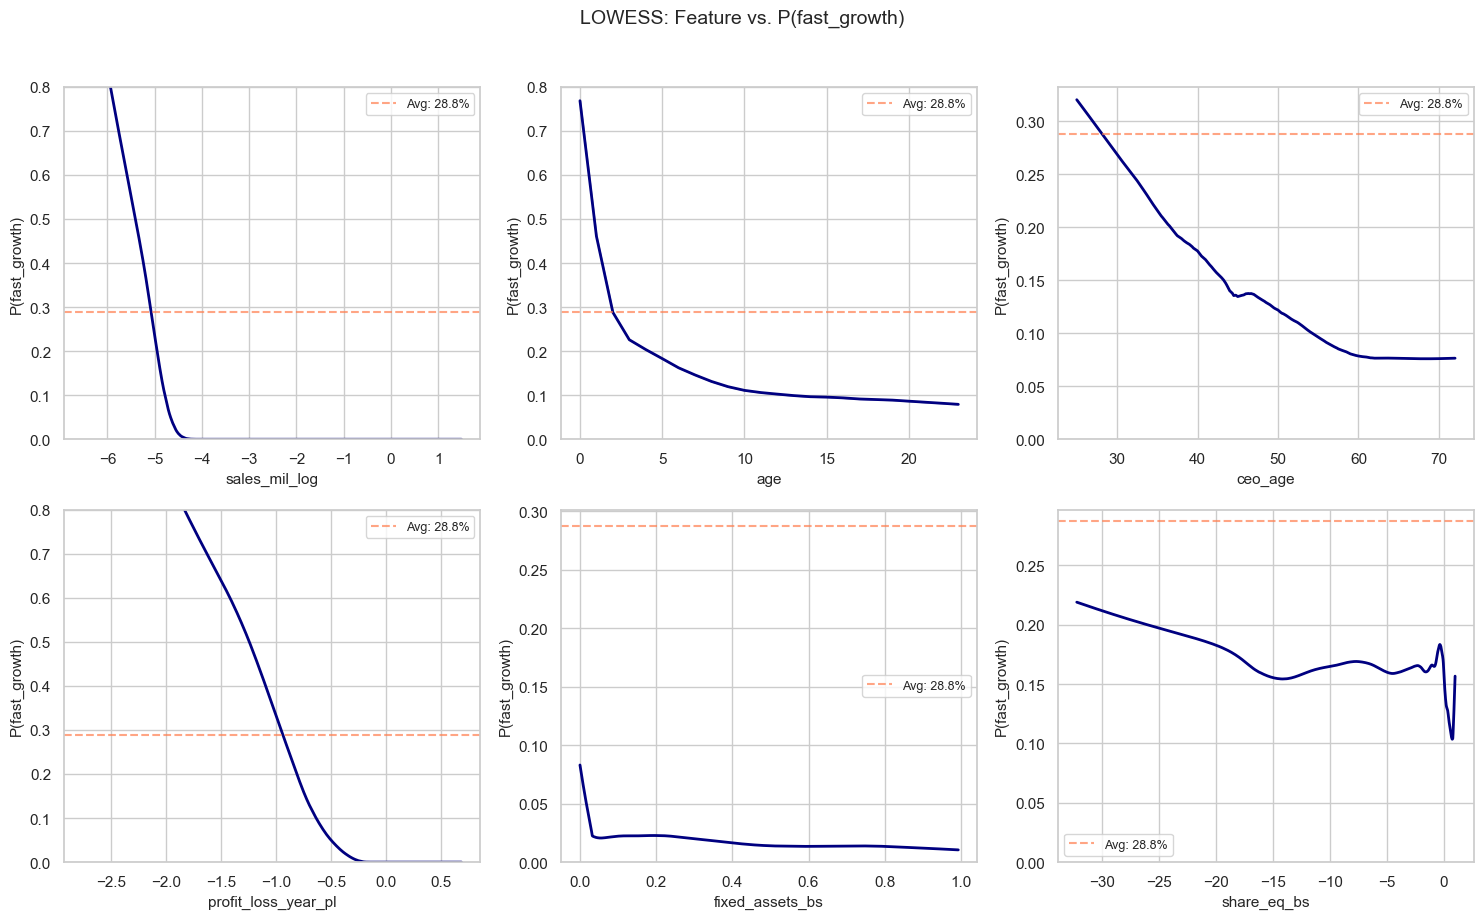

In [25]:
# LOWESS, continuous features vs. fast_growth
from statsmodels.nonparametric.smoothers_lowess import lowess

sns.set_theme(style="whitegrid", palette="deep")

lowess_vars = ["sales_mil_log", "age", "ceo_age", 
               "profit_loss_year_pl", "fixed_assets_bs", "share_eq_bs"]

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
avg_rate = data["fast_growth"].mean()

for ax, var in zip(axes.flatten(), lowess_vars):
    sorted_data = data[[var, "fast_growth"]].dropna().sort_values(var)
    
    # Trim to 1st–99th percentile for cleaner plots
    p01, p99 = sorted_data[var].quantile([0.01, 0.99])
    plot_data = sorted_data.query(f"{p01} <= {var} <= {p99}")
    
    smooth = lowess(plot_data["fast_growth"], plot_data[var], 
                    frac=0.3, return_sorted=True)
    
    sns.lineplot(x=smooth[:, 0], y=smooth[:, 1], ax=ax, 
                 color="navy", linewidth=2)
    ax.axhline(y=avg_rate, color="coral", linestyle="--", 
               alpha=0.7, label=f"Avg: {avg_rate:.1%}")
    ax.set_xlabel(var, fontsize=11)
    ax.set_ylabel("P(fast_growth)", fontsize=11)
    ax.set_ylim(0, min(ax.get_ylim()[1], 0.8))  # cap y-axis
    ax.legend(fontsize=9)

fig.suptitle("LOWESS: Feature vs. P(fast_growth)", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("../outputs/lowess_fast_growth.png", dpi=150, bbox_inches="tight")
plt.show()

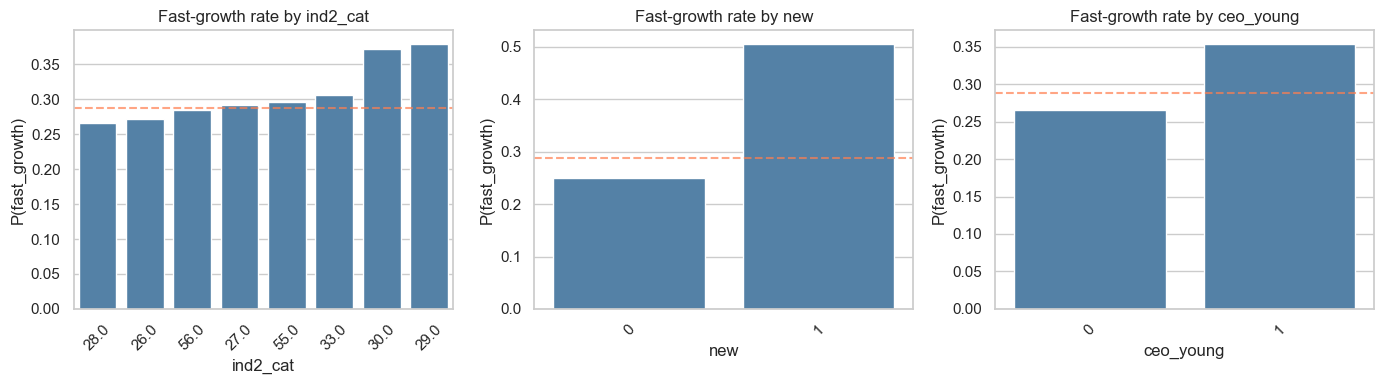

In [26]:
# bar chart: fast-growth rate by key categories
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, var in zip(axes, ["ind2_cat", "new", "ceo_young"]):
    rates = data.groupby(var)["fast_growth"].mean().sort_values()
    sns.barplot(x=rates.index.astype(str), y=rates.values, 
                ax=ax, color="steelblue")
    ax.axhline(y=avg_rate, color="coral", linestyle="--", alpha=0.7)
    ax.set_ylabel("P(fast_growth)")
    ax.set_title(f"Fast-growth rate by {var}")
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig("../outputs/factors_fast_growth.png", dpi=150, bbox_inches="tight")
plt.show()

## Key observations from exploratory analysis
- Firm age is the strongest signal: new firms (age ≤ 1) have ~51% fast-growth rate vs. ~25% for established firms
- Smaller firms show higher fast-growth probability; this nonlinear relationship justifies quadratic term in sales_mil_log
- Younger CEOs (<40) associated with higher growth (35% vs 27%)
- profit_loss_year_pl shows strong nonlinear pattern; firms with losses more likely to be fast-growing (investing for growth)
- Asset-light firms (low fixed_assets_bs) more likely fast-growth
- Industry differences modest; gender/region weak predictors

## save prepped data for modeling

In [27]:
# save prepped data ──
data.to_csv("../data/prepped/bisnode_firms_prepped.csv", index=False)
print("Saved to data/prepped/bisnode_firms_prepped.csv")

Saved to data/prepped/bisnode_firms_prepped.csv
